# Day 2 — Linear Regression

A complete walkthrough of Linear Regression covering:
- **Part 1**: Simple Linear Regression from Scratch (using Advertising data)
- **Part 2**: Simple Linear Regression with Scikit-Learn
- **Part 3**: EDA, Correlation Analysis & Multiple Linear Regression on a real dataset
- **Part 4**: AutoML with PyCaret

# Part 1 — Simple Linear Regression from Scratch

In this part, we create a small advertising dataset (similar to the one used in Analytics Vidhya's linear regression tutorial) and implement simple linear regression **from scratch** using the closed-form formula.

**Key Formulas:**
- Slope: $b_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$
- Intercept: $b_0 = \bar{y} - b_1 \cdot \bar{x}$
- Best Fit Line: $\hat{y} = b_0 + b_1 \cdot x$

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Step 2: Create the Advertising DataFrame
# This dataset shows the relationship between advertising spend (TV, Radio, Newspaper)
# and Sales. We use a subset similar to the Analytics Vidhya tutorial.
# TV spend (in thousands) is our independent variable, Sales is the target.

data = {
    'TV': [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8,
           66.1, 214.7, 23.8, 97.5, 204.1, 195.4, 67.8, 281.4, 69.2, 147.3],
    'Radio': [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6,
              5.8, 24.0, 35.1, 7.6, 32.9, 47.7, 36.6, 39.6, 20.5, 23.9],
    'Newspaper': [69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 1.0, 21.2,
                  24.2, 4.0, 65.9, 7.2, 46.0, 52.9, 114.0, 55.8, 18.3, 19.1],
    'Sales': [22.1, 10.4, 12.0, 16.5, 17.9, 7.2, 11.8, 13.2, 4.8, 10.6,
              8.6, 17.4, 9.2, 9.7, 17.0, 22.4, 12.5, 24.4, 11.3, 14.6]
}

# pd.DataFrame() converts a dictionary into a tabular structure (rows & columns)
advertising = pd.DataFrame(data)
print("Advertising Dataset Shape:", advertising.shape)  # (rows, columns)
advertising.head(10)  # Display first 10 rows to verify data loaded correctly

Advertising Dataset Shape: (20, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


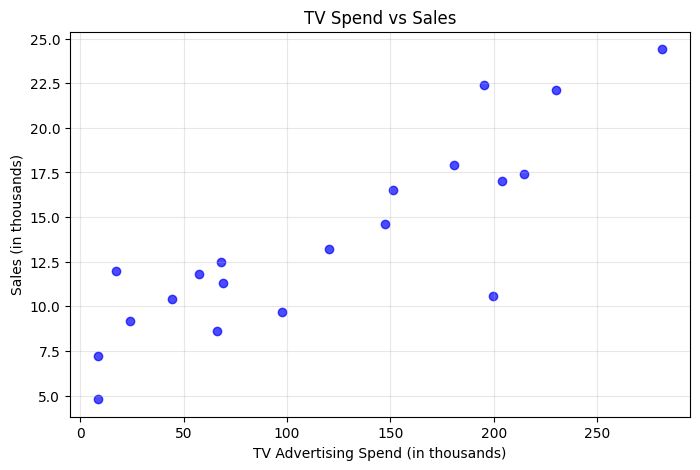

In [3]:
# Step 3: Visualize the relationship between TV spend and Sales
# We choose TV as the predictor because it has the highest correlation with Sales
plt.figure(figsize=(8, 5))  # Create a figure with 8x5 inch dimensions
plt.scatter(advertising['TV'], advertising['Sales'], color='blue', alpha=0.7)  # alpha controls transparency
plt.xlabel('TV Advertising Spend (in thousands)')  # Label for x-axis
plt.ylabel('Sales (in thousands)')  # Label for y-axis
plt.title('TV Spend vs Sales')
plt.grid(True, alpha=0.3)  # Add light gridlines for readability
plt.show()  # Render the plot

Correlation with Sales:
Sales        1.000000
TV           0.863900
Radio        0.394829
Newspaper    0.249057
Name: Sales, dtype: float64



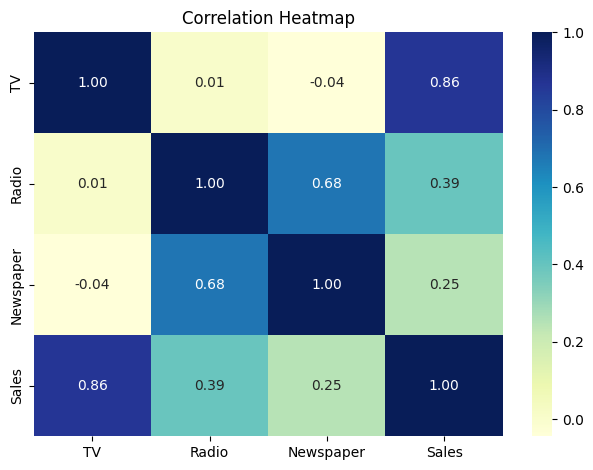

In [4]:
# Step 4: Check correlations — TV has the highest correlation with Sales
print("Correlation with Sales:")
# .corr() computes pairwise Pearson correlation between all columns
# ['Sales'] selects only correlations with the target column
print(advertising.corr()['Sales'].sort_values(ascending=False))
print()

# Heatmap for quick visual reference
# annot=True shows correlation values inside cells, fmt='.2f' formats to 2 decimals
sns.heatmap(advertising.corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.tight_layout()  # Prevents labels from being cut off
plt.show()

In [5]:
# Step 5: Prepare data for Simple Linear Regression
# X = TV (independent variable), y = Sales (dependent variable)
X = advertising['TV'].values  # .values converts pandas Series to NumPy array
y = advertising['Sales'].values  # NumPy arrays are faster for mathematical operations

print(f"Number of samples: {len(X)}")
print(f"X (TV) range: {X.min():.1f} to {X.max():.1f}")
print(f"y (Sales) range: {y.min():.1f} to {y.max():.1f}")

Number of samples: 20
X (TV) range: 8.6 to 281.4
y (Sales) range: 4.8 to 24.4


In [13]:
# Step 6: Simple Linear Regression from Scratch (Closed-Form Formula)
#
# The direct formula to compute slope and intercept WITHOUT iteration:
#
#   slope (b1) = Σ((xi - x̄)(yi - ȳ)) / Σ((xi - x̄)²)
#   intercept (b0) = ȳ - b1 * x̄
#
# This gives the EXACT optimal values in one shot — no cost function or gradients needed.

# --- STEP 1: Compute the mean of X and y ---
x_mean = np.mean(X)  # Mean of TV spend
y_mean = np.mean(y)  # Mean of Sales
print(f"STEP 1 — Compute means:")
print(f"  x̄ (mean of TV)    = {x_mean:.2f}")
print(f"  ȳ (mean of Sales) = {y_mean:.2f}")
print()

# --- STEP 2: Compute deviations from the mean ---
# (xi - x̄) = how far each X is from the average
# (yi - ȳ) = how far each y is from the average
x_deviation = X - x_mean  # Deviation of each X from mean
y_deviation = y - y_mean  # Deviation of each y from mean
print(f"STEP 2 — Deviations from mean:")
print(f"  (xi - x̄) = {x_deviation}")
print(f"  (yi - ȳ) = {y_deviation}")
print()

# --- STEP 3: Compute the numerator and denominator for slope ---
# Numerator: Σ((xi - x̄)(yi - ȳ)) — measures how X and y move together
# Denominator: Σ((xi - x̄)²) — measures how spread out X is
numerator = np.sum(x_deviation * y_deviation)  # Cross-deviation product
denominator = np.sum(x_deviation ** 2)          # Squared deviation of X
print(f"STEP 3 — Slope components:")
print(f"  Numerator   Σ((xi - x̄)(yi - ȳ)) = {numerator:.4f}")
print(f"  Denominator Σ((xi - x̄)²)        = {denominator:.4f}")
print()

# --- STEP 4: Compute slope (b1) ---
b1 = numerator / denominator  # Slope = rise / run (in deviation terms)
print(f"STEP 4 — Slope (b1):")
print(f"  b1 = {numerator:.4f} / {denominator:.4f} = {b1:.6f}")
print()

# --- STEP 5: Compute intercept (b0) ---
b0 = y_mean - b1 * x_mean  # Intercept = ȳ - b1 * x̄
print(f"STEP 5 — Intercept (b0):")
print(f"  b0 = {y_mean:.2f} - {b1:.6f} * {x_mean:.2f} = {b0:.4f}")
print()

# --- FINAL RESULT ---
print("=" * 50)
print("SIMPLE LINEAR REGRESSION (From Scratch)")
print("=" * 50)
print(f"  Intercept (b0): {b0:.4f}")
print(f"  Slope (b1):     {b1:.6f}")
print(f"\n  Equation: Sales = {b0:.4f} + {b1:.6f} × TV")
print(f"\n  Meaning: For every $1K increase in TV spend,")
print(f"  Sales increase by ${b1*1000:.2f}")

STEP 1 — Compute means:
  x̄ (mean of TV)    = 119.31
  ȳ (mean of Sales) = 13.68

STEP 2 — Deviations from mean:
  (xi - x̄) = [ 110.79  -74.81 -102.11   32.19   61.49 -110.61  -61.81    0.89 -110.71
   80.49  -53.21   95.39  -95.51  -21.81   84.79   76.09  -51.51  162.09
  -50.11   27.99]
  (yi - ȳ) = [ 8.42 -3.28 -1.68  2.82  4.22 -6.48 -1.88 -0.48 -8.88 -3.08 -5.08  3.72
 -4.48 -3.98  3.32  8.72 -1.18 10.72 -2.38  0.92]

STEP 3 — Slope components:
  Numerator   Σ((xi - x̄)(yi - ȳ)) = 7296.0140
  Denominator Σ((xi - x̄)²)        = 134634.1380

STEP 4 — Slope (b1):
  b1 = 7296.0140 / 134634.1380 = 0.054191

STEP 5 — Intercept (b0):
  b0 = 13.68 - 0.054191 * 119.31 = 7.2144

SIMPLE LINEAR REGRESSION (From Scratch)
  Intercept (b0): 7.2144
  Slope (b1):     0.054191

  Equation: Sales = 7.2144 + 0.054191 × TV

  Meaning: For every $1K increase in TV spend,
  Sales increase by $54.19


In [11]:
# Verify: Manual calculation matches the formula
# Let's compute numerator and denominator element by element

print("VERIFICATION — Element-by-element calculation:")
print(f"{'i':>3} {'xi':>8} {'yi':>8} {'xi-x̄':>10} {'yi-ȳ':>10} {'(xi-x̄)(yi-ȳ)':>15} {'(xi-x̄)²':>12}")
print("-" * 70)

total_num = 0
total_den = 0
for i in range(len(X)):
    xd = X[i] - x_mean
    yd = y[i] - y_mean
    prod = xd * yd
    sq = xd ** 2
    total_num += prod
    total_den += sq
    print(f"{i+1:>3} {X[i]:>8.1f} {y[i]:>8.1f} {xd:>10.2f} {yd:>10.2f} {prod:>15.4f} {sq:>12.4f}")

print("-" * 70)
print(f"{'SUM':>3} {'':>8} {'':>8} {'':>10} {'':>10} {total_num:>15.4f} {total_den:>12.4f}")
print()
print(f"Slope (b1)     = {total_num:.4f} / {total_den:.4f} = {total_num/total_den:.6f}")
print(f"Intercept (b0) = {y_mean:.2f} - {total_num/total_den:.6f} × {x_mean:.2f} = {y_mean - (total_num/total_den) * x_mean:.4f}")

# Store as theta0, theta1 for use in later cells
theta0 = b0
theta1 = b1

VERIFICATION — Element-by-element calculation:
  i       xi       yi      xi-x̄       yi-ȳ   (xi-x̄)(yi-ȳ)     (xi-x̄)²
----------------------------------------------------------------------
  1    230.1     22.1     110.79       8.42        932.8518   12274.4241
  2     44.5     10.4     -74.81      -3.28        245.3768    5596.5361
  3     17.2     12.0    -102.11      -1.68        171.5448   10426.4521
  4    151.5     16.5      32.19       2.82         90.7758    1036.1961
  5    180.8     17.9      61.49       4.22        259.4878    3781.0201
  6      8.7      7.2    -110.61      -6.48        716.7528   12234.5721
  7     57.5     11.8     -61.81      -1.88        116.2028    3820.4761
  8    120.2     13.2       0.89      -0.48         -0.4272       0.7921
  9      8.6      4.8    -110.71      -8.88        983.1048   12256.7041
 10    199.8     10.6      80.49      -3.08       -247.9092    6478.6401
 11     66.1      8.6     -53.21      -5.08        270.3068    2831.3041
 12   

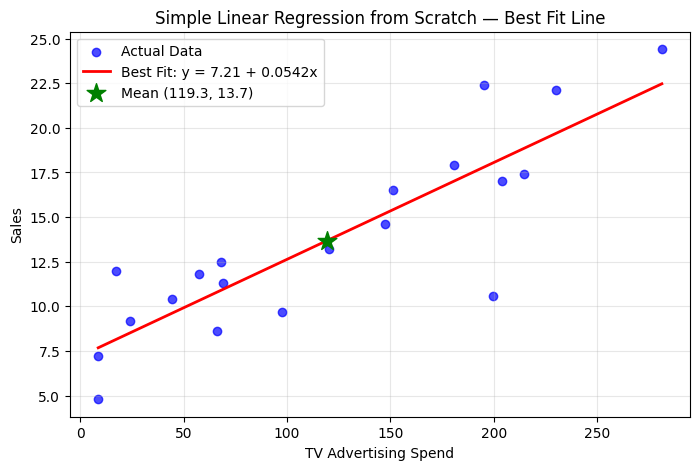

In [14]:
# Step 7: Plot the Best Fit Line on the scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data')  # Plot original data points

# Generate 100 evenly spaced points for a smooth regression line
x_line = np.linspace(X.min(), X.max(), 100)  # np.linspace creates evenly spaced values
y_line = b0 + b1 * x_line  # Apply our computed equation to get predicted y values
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Best Fit: y = {b0:.2f} + {b1:.4f}x')

# Mark the mean point (x̄, ȳ) — the regression line always passes through this point
plt.scatter(x_mean, y_mean, color='green', s=200, zorder=5, marker='*', label=f'Mean ({x_mean:.1f}, {y_mean:.1f})')

plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('Simple Linear Regression from Scratch — Best Fit Line')
plt.legend()  # Show legend with labels defined above
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Step 9: Evaluate the model from scratch
# Compute predictions using the learned parameters
y_pred_scratch = theta0 + theta1 * X  # Apply best fit equation to all X values

# MSE: Average of squared differences — penalizes large errors more heavily
mse_scratch = np.mean((y - y_pred_scratch) ** 2)

# RMSE: Square root of MSE — brings error back to same unit as target (Sales)
rmse_scratch = np.sqrt(mse_scratch)

# MAE: Average of absolute differences — treats all errors equally
mae_scratch = np.mean(np.abs(y - y_pred_scratch))

# R-squared: How much variance in y is explained by the model (1.0 = perfect)
ss_res = np.sum((y - y_pred_scratch) ** 2)  # RSS: sum of squared residuals (unexplained variance)
ss_tot = np.sum((y - np.mean(y)) ** 2)      # TSS: total variance in y (baseline)
r2_scratch = 1 - (ss_res / ss_tot)          # R² = 1 - (unexplained / total)

print("=" * 40)
print("MODEL EVALUATION (From Scratch)")
print("=" * 40)
print(f"Mean Squared Error (MSE):  {mse_scratch:.4f}")
print(f"Root Mean Squared Error:   {rmse_scratch:.4f}")
print(f"Mean Absolute Error (MAE): {mae_scratch:.4f}")
print(f"R-squared (R²):            {r2_scratch:.4f}")
print(f"\nInterpretation: {r2_scratch*100:.1f}% of variance in Sales is explained by TV spend")

MODEL EVALUATION (From Scratch)
Mean Squared Error (MSE):  6.7195
Root Mean Squared Error:   2.5922
Mean Absolute Error (MAE): 1.9652
R-squared (R²):            0.7463

Interpretation: 74.6% of variance in Sales is explained by TV spend


# Part 2 — Simple Linear Regression with Scikit-Learn

Now we perform the same linear regression using Scikit-Learn's `LinearRegression` class.  
This validates our from-scratch implementation and demonstrates the standard ML workflow:
1. Split data into Train/Test sets
2. Fit the model
3. Predict on test set
4. Evaluate performance

In [16]:
# Step 1: Import sklearn modules
from sklearn.model_selection import train_test_split  # Splits data into train/test sets
from sklearn.linear_model import LinearRegression     # OLS-based linear regression model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Evaluation metrics

In [17]:
# Step 2: Prepare features and target
# sklearn expects X to be 2D array with shape (n_samples, n_features)
# Using [['TV']] (double brackets) returns a DataFrame (2D), not a Series (1D)
X_tv = advertising[['TV']].values  # Shape: (20, 1) — required format for sklearn
y_sales = advertising['Sales'].values  # Shape: (20,) — 1D target array

# Split into 70% training and 30% testing
# train_test_split randomly shuffles and splits the data
# random_state=100 ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X_tv, y_sales, train_size=0.7, test_size=0.3, random_state=100
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 14 samples
Test set size:     6 samples


In [18]:
# Step 3: Fit the Linear Regression model
# LinearRegression uses Ordinary Least Squares (OLS) — finds the exact solution
# Unlike gradient descent, OLS computes the optimal parameters in one step
lr_model = LinearRegression()  # Create the model object
lr_model.fit(X_train, y_train)  # .fit() learns the optimal coefficients from training data

# Extract the learned parameters
# intercept_ = B0 (value of y when all features are 0)
# coef_ = array of slopes (one per feature)
print("Model Parameters (sklearn):")
print(f"  Intercept (B0): {lr_model.intercept_:.4f}")
print(f"  Slope (B1):     {lr_model.coef_[0]:.6f}")
print(f"\nEquation: Sales = {lr_model.intercept_:.4f} + {lr_model.coef_[0]:.6f} * TV")
print(f"\nComparison with our from-scratch model:")
print(f"  From Scratch → theta0={theta0:.4f}, theta1={theta1:.6f}")
print(f"  Sklearn      → B0={lr_model.intercept_:.4f}, B1={lr_model.coef_[0]:.6f}")

Model Parameters (sklearn):
  Intercept (B0): 7.4140
  Slope (B1):     0.053077

Equation: Sales = 7.4140 + 0.053077 * TV

Comparison with our from-scratch model:
  From Scratch → theta0=7.2144, theta1=0.054191
  Sklearn      → B0=7.4140, B1=0.053077


In [19]:
# Step 4: Make predictions on the test set
# .predict() applies the learned equation (B0 + B1*X) to unseen test data
y_pred = lr_model.predict(X_test)

# Create a comparison DataFrame to see actual vs predicted side by side
comparison = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred.flatten()})
comparison['Error'] = comparison['Actual Sales'] - comparison['Predicted Sales']  # Residual
print("Actual vs Predicted Sales on Test Set:")
comparison

Actual vs Predicted Sales on Test Set:


,Actual Sales,Predicted Sales,Error
0,24.4,22.350023,2.049977
1,14.6,15.232347,-0.632347
2,17.4,18.809762,-1.409762
3,11.3,11.087004,0.212996
4,9.7,12.589094,-2.889094
5,11.8,10.465999,1.334001


In [20]:
# Step 5: Evaluate the sklearn model using standard metrics
# These sklearn functions compute the same metrics we calculated manually in Part 1
mse_sklearn = mean_squared_error(y_test, y_pred)    # Average squared error
rmse_sklearn = np.sqrt(mse_sklearn)                  # Square root of MSE
mae_sklearn = mean_absolute_error(y_test, y_pred)    # Average absolute error
r2_sklearn = r2_score(y_test, y_pred)                # Proportion of variance explained (0 to 1)

print("=" * 40)
print("MODEL EVALUATION (Scikit-Learn)")
print("=" * 40)
print(f"Mean Squared Error (MSE):  {mse_sklearn:.4f}")
print(f"Root Mean Squared Error:   {rmse_sklearn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_sklearn:.4f}")
print(f"R-squared (R²):            {r2_sklearn:.4f}")
print(f"\nInterpretation: {r2_sklearn*100:.1f}% of variance in Sales is explained by TV spend")

MODEL EVALUATION (Scikit-Learn)
Mean Squared Error (MSE):  2.7936
Root Mean Squared Error:   1.6714
Mean Absolute Error (MAE): 1.4214
R-squared (R²):            0.8853

Interpretation: 88.5% of variance in Sales is explained by TV spend


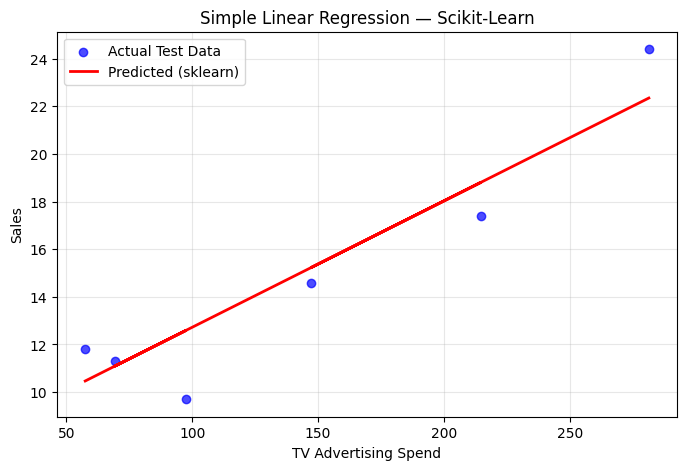

In [21]:
# Step 6: Visualize the regression line on test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted (sklearn)')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('Simple Linear Regression — Scikit-Learn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Part 3 — EDA, Correlation Analysis & Linear Regression (Real Dataset)

In this part, we use the **California Housing** dataset from Scikit-Learn.  
We perform the complete ML pipeline:
1. Load and explore the dataset (EDA)
2. Handle missing values, check distributions
3. Correlation analysis (heatmap, pairplot)
4. Feature selection based on correlation
5. Train/Test split
6. Fit Multiple Linear Regression with sklearn
7. Model evaluation with all error metrics

In [26]:
# Step 1: Load the California Housing Dataset
# Fix for macOS SSL certificate issue — install a custom HTTPS handler
import ssl, urllib.request
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE
urllib.request.install_opener(urllib.request.build_opener(
    urllib.request.HTTPSHandler(context=ctx)))

# This dataset contains information about houses in California districts
# Target: MedHouseVal (Median House Value in $100,000s)
from sklearn.datasets import fetch_california_housing

# fetch_california_housing() returns a Bunch object with .data, .target, .feature_names
housing = fetch_california_housing()

# Convert to DataFrame for easier manipulation and visualization
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Add target column to the DataFrame

print("California Housing Dataset")
print(f"Shape: {df.shape}")  # (20640 rows, 9 columns)
print(f"\nFeatures: {list(housing.feature_names)}")
print(f"Target: MedHouseVal (Median House Value in $100,000s)")
print(f"\nDescription:\n{housing.DESCR[:500]}")

California Housing Dataset
Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (Median House Value in $100,000s)

Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu


In [27]:
# Step 2: Exploratory Data Analysis (EDA)
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [28]:
# Data types and memory usage
print("Data Types and Non-Null Counts:")
df.info()

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [29]:
# Statistical summary — check distributions, min/max, mean, std
print("Statistical Summary:")
df.describe()

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [30]:
# Check for missing values
# Good practice: always check before building models
# .isnull() returns True/False for each cell, .sum() counts True values per column
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("No missing values in this dataset — ready for modeling!")

Missing Values per Column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0
No missing values in this dataset — ready for modeling!


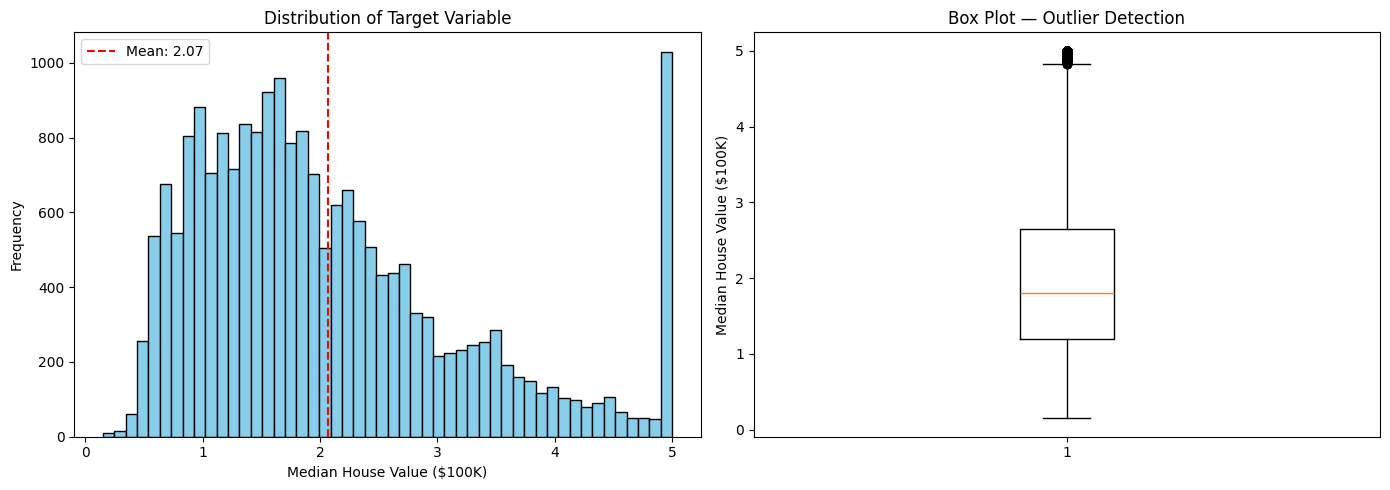

Target is capped at 5.0 ($500K) — there's a ceiling effect in the data


In [31]:
# Distribution of the target variable (MedHouseVal)
# Understanding the target helps interpret model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns of subplots

# Histogram: shows frequency distribution of house values
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Median House Value ($100K)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable')
# axvline draws a vertical line at the mean value for reference
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Mean: {df['MedHouseVal'].mean():.2f}")
axes[0].legend()

# Box plot: shows median, quartiles, and outliers (points beyond whiskers)
axes[1].boxplot(df['MedHouseVal'])
axes[1].set_ylabel('Median House Value ($100K)')
axes[1].set_title('Box Plot — Outlier Detection')

plt.tight_layout()  # Adjusts spacing to prevent overlap
plt.show()

print(f"Target is capped at 5.0 ($500K) — there's a ceiling effect in the data")

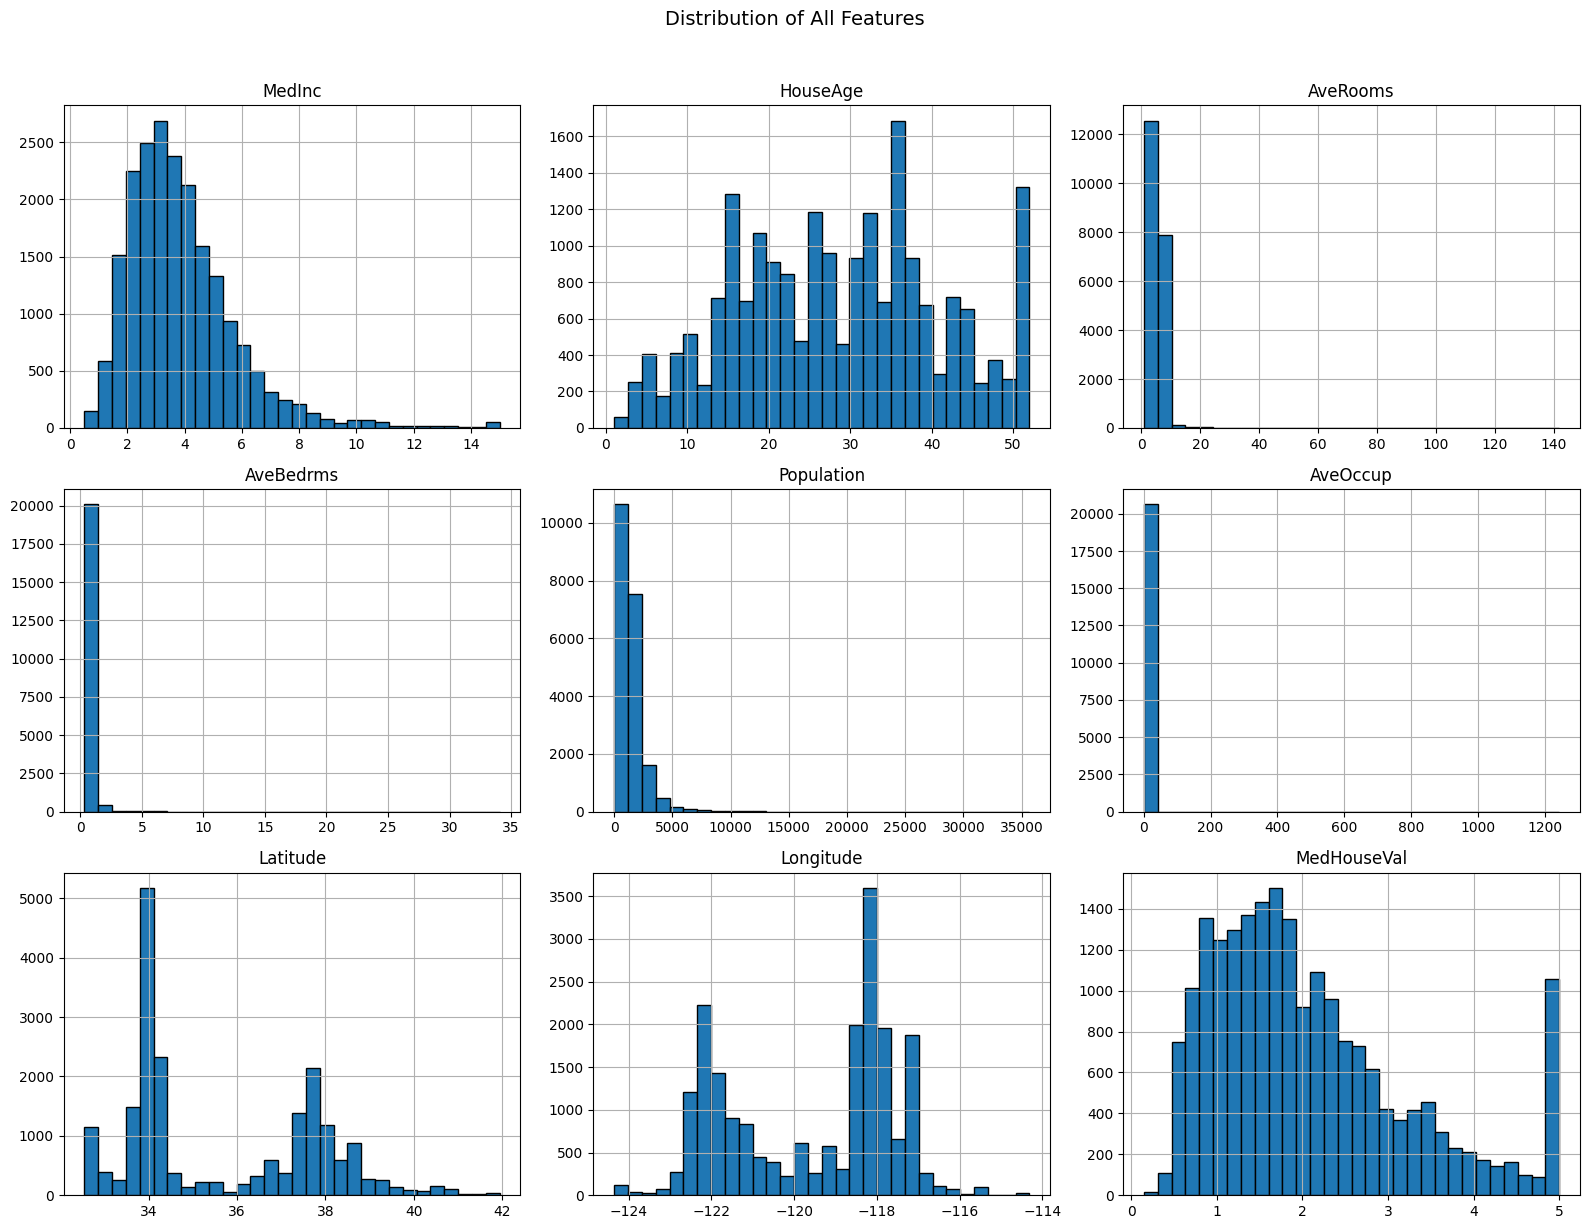

In [32]:
# Distribution of all features using histograms
# This helps identify skewness, outliers, and feature ranges
df.hist(bins=30, figsize=(16, 12), edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation tells us how strongly two variables are linearly related.  
- Values close to **+1** = strong positive correlation  
- Values close to **-1** = strong negative correlation  
- Values close to **0** = no linear relationship  

We use this to select the best features for our regression model.

In [33]:
# Correlation matrix — numerical summary
# .corr() computes Pearson correlation coefficient between every pair of columns
# Values range from -1 (perfect negative) to +1 (perfect positive)
correlation_matrix = df.corr()

# Sort correlations with target to identify most predictive features
print("Correlation with Target (MedHouseVal):")
print(correlation_matrix['MedHouseVal'].sort_values(ascending=False))
print("\nKey Insight: MedInc (Median Income) has the highest correlation with house value")

Correlation with Target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

Key Insight: MedInc (Median Income) has the highest correlation with house value


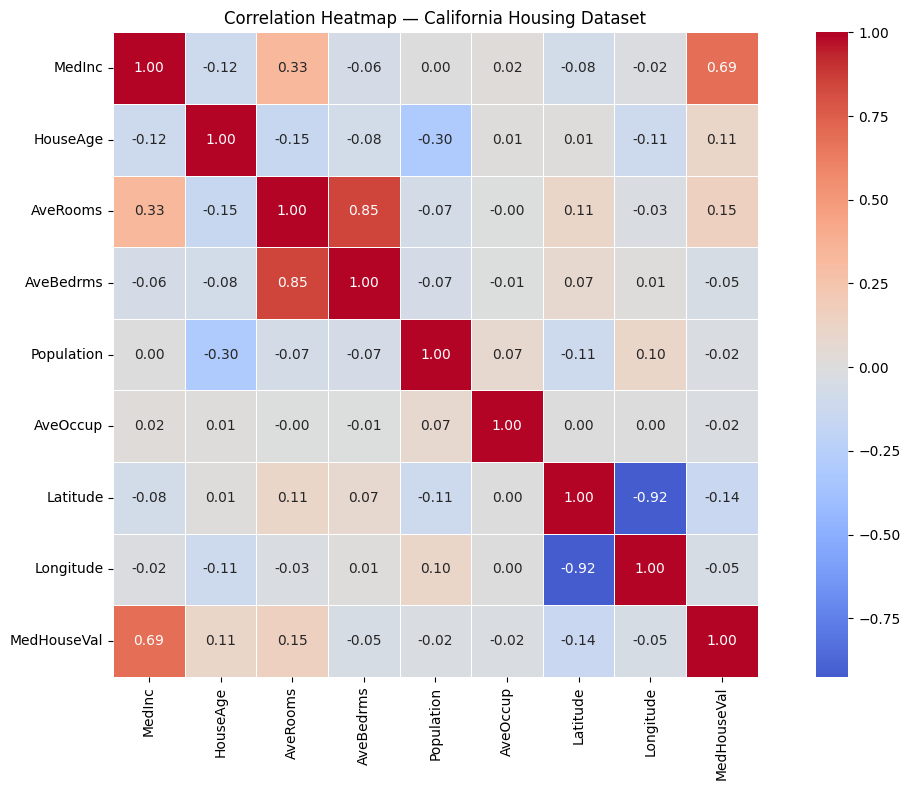

In [34]:
# Correlation Heatmap — visual representation of the correlation matrix
plt.figure(figsize=(12, 8))
# annot=True: display numbers in each cell
# cmap='coolwarm': blue for negative, red for positive correlations
# center=0: ensures 0 correlation is neutral color
# square=True: makes cells square-shaped for better readability
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — California Housing Dataset')
plt.tight_layout()
plt.show()

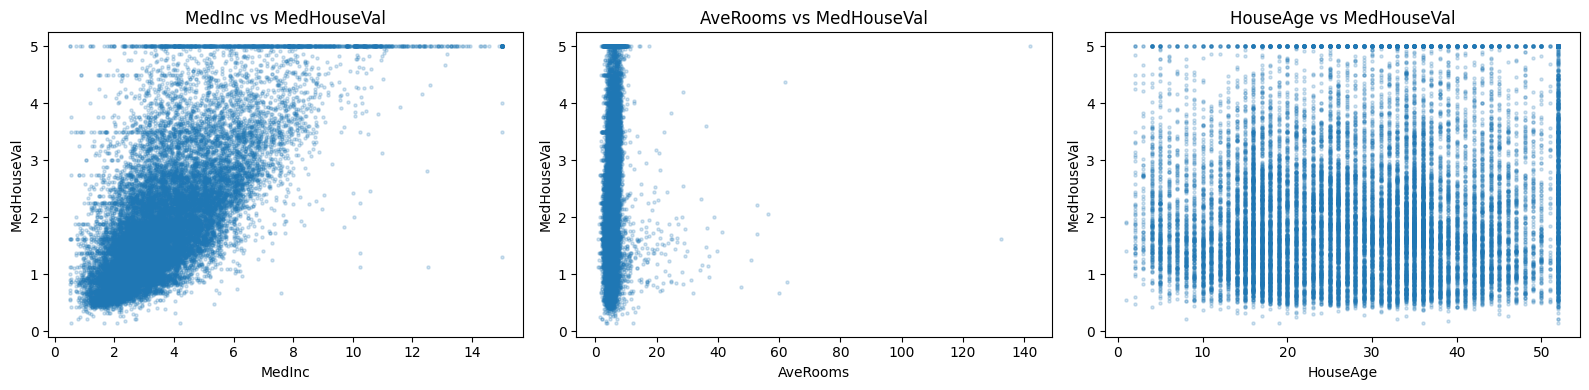

In [35]:
# Scatter plots: Top correlated features vs Target
# This gives us a visual understanding of the linear relationship
top_features = ['MedInc', 'AveRooms', 'HouseAge']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['MedHouseVal'], alpha=0.2, s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'{feature} vs MedHouseVal')
    
plt.tight_layout()
plt.show()

## Multiple Linear Regression with Scikit-Learn

Using all features to build a multiple linear regression model:  
$Y = B_0 + B_1X_1 + B_2X_2 + ... + B_nX_n$

In [36]:
# Step 3: Prepare features and target for Multiple Linear Regression
# .drop() removes the target column, leaving only feature columns
X_housing = df.drop('MedHouseVal', axis=1)  # axis=1 means drop a column (not a row)
y_housing = df['MedHouseVal']                # Target variable (what we predict)

# Split into 80% train and 20% test
# random_state=42 ensures the same split every time for reproducibility
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train_h.shape[0]}")  # 80% of 20640 ≈ 16512
print(f"Test samples:     {X_test_h.shape[0]}")   # 20% of 20640 ≈ 4128
print(f"Number of features: {X_train_h.shape[1]}")  # 8 features

Training samples: 16512
Test samples:     4128
Number of features: 8


In [37]:
# Step 4: Fit Multiple Linear Regression
# Same LinearRegression class — sklearn handles multiple features automatically
mlr_model = LinearRegression()
mlr_model.fit(X_train_h, y_train_h)  # Learns 8 coefficients + 1 intercept

# Display model parameters
# intercept_ = B0 (baseline prediction when all features are 0)
print("Multiple Linear Regression Model Parameters:")
print(f"  Intercept (B0): {mlr_model.intercept_:.4f}")
# coef_ = array of B1, B2, ..., B8 (one coefficient per feature)
print(f"\n  Feature Coefficients:")
print("  " + "-" * 35)
for feature, coef in zip(X_housing.columns, mlr_model.coef_):
    print(f"  {feature:12s}: {coef:>10.6f}")

# Coefficient interpretation: each coef shows the change in target per 1-unit change in feature
print(f"\nInterpretation: For every 1 unit increase in MedInc,")
print(f"house value increases by ~${mlr_model.coef_[0]*100000:.0f} (holding others constant)")

Multiple Linear Regression Model Parameters:
  Intercept (B0): -37.0233

  Feature Coefficients:
  -----------------------------------
  MedInc      :   0.448675
  HouseAge    :   0.009724
  AveRooms    :  -0.123323
  AveBedrms   :   0.783145
  Population  :  -0.000002
  AveOccup    :  -0.003526
  Latitude    :  -0.419792
  Longitude   :  -0.433708

Interpretation: For every 1 unit increase in MedInc,
house value increases by ~$44867 (holding others constant)


In [38]:
# Step 5: Make predictions on test set
y_pred_h = mlr_model.predict(X_test_h)

# Display first 10 predictions vs actual
results = pd.DataFrame({'Actual': y_test_h.values[:10], 'Predicted': y_pred_h[:10]})
results['Error'] = results['Actual'] - results['Predicted']
results['Error %'] = (results['Error'] / results['Actual'] * 100).round(1)
print("First 10 Predictions vs Actual:")
results

First 10 Predictions vs Actual:


,Actual,Predicted,Error,Error %
0,0.47700,0.719123,-0.242123,-50.8
1,0.45800,1.764017,-1.306017,-285.2
2,5.00001,2.709659,2.290351,45.8
3,2.18600,2.838926,-0.652926,-29.9
4,2.78000,2.604657,0.175343,6.3
5,1.58700,2.011754,-0.424754,-26.8
6,1.98200,2.645500,-0.663500,-33.5
7,1.57500,2.168755,-0.593755,-37.7
8,3.40000,2.740746,0.659254,19.4
9,4.46600,3.915615,0.550385,12.3


## Model Evaluation

We evaluate using multiple metrics:
- **MAE** (Mean Absolute Error): Average magnitude of errors
- **MSE** (Mean Squared Error): Average squared errors (penalizes large errors)
- **RMSE** (Root MSE): Same unit as target variable
- **R²** (R-squared): Proportion of variance explained (0 to 1, higher is better)

In [39]:
# Step 6: Compute evaluation metrics on BOTH train and test sets
# Comparing train vs test helps detect overfitting
# If train R² >> test R², the model memorized training data (overfitting)

# Training set metrics — how well the model fits data it learned from
y_pred_train = mlr_model.predict(X_train_h)  # Predictions on training data
train_mae = mean_absolute_error(y_train_h, y_pred_train)
train_mse = mean_squared_error(y_train_h, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_h, y_pred_train)

# Test set metrics — how well the model generalizes to unseen data (TRUE performance)
test_mae = mean_absolute_error(y_test_h, y_pred_h)
test_mse = mean_squared_error(y_test_h, y_pred_h)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_h, y_pred_h)

print("=" * 55)
print("MODEL EVALUATION — Multiple Linear Regression")
print("=" * 55)
print(f"{'Metric':<25} {'Train':<15} {'Test':<15}")
print("-" * 55)
print(f"{'MAE':<25} {train_mae:<15.4f} {test_mae:<15.4f}")
print(f"{'MSE':<25} {train_mse:<15.4f} {test_mse:<15.4f}")
print(f"{'RMSE':<25} {train_rmse:<15.4f} {test_rmse:<15.4f}")
print(f"{'R² Score':<25} {train_r2:<15.4f} {test_r2:<15.4f}")
print("-" * 55)
print(f"\nInterpretation:")
print(f"  • R² = {test_r2:.4f} → {test_r2*100:.1f}% of variance explained by the model")
print(f"  • RMSE = {test_rmse:.4f} → Average prediction error is ~${test_rmse*100000:.0f}")
print(f"  • Train and Test R² are similar → No significant overfitting")

MODEL EVALUATION — Multiple Linear Regression
Metric                    Train           Test           
-------------------------------------------------------
MAE                       0.5286          0.5332         
MSE                       0.5179          0.5559         
RMSE                      0.7197          0.7456         
R² Score                  0.6126          0.5758         
-------------------------------------------------------

Interpretation:
  • R² = 0.5758 → 57.6% of variance explained by the model
  • RMSE = 0.7456 → Average prediction error is ~$74558
  • Train and Test R² are similar → No significant overfitting


In [ ]:
# Step 7: Visualize model performance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted — points on the red line = perfect predictions
axes[0].scatter(y_test_h, y_pred_h, alpha=0.3, s=5)  # Each point is one test sample
axes[0].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 
             'r--', linewidth=2, label='Perfect Prediction')  # 45-degree reference line
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs Predicted — Multiple Linear Regression')
axes[0].legend()

# Plot 2: Residual Distribution — should be bell-shaped (normal) centered at 0
# If residuals are normally distributed, linear regression assumptions are met
residuals = y_test_h - y_pred_h  # Residual = Actual - Predicted
axes[1].hist(residuals, bins=50, edgecolor='black', color='skyblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)  # Reference line at 0
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution (should be centered at 0)')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {residuals.mean():.6f} (close to 0 = good)")
print(f"Std of residuals:  {residuals.std():.4f}")

# Part 4 — AutoML with PyCaret

PyCaret is a low-code ML library that automates the entire ML workflow.  
It compares multiple models, tunes hyperparameters, and evaluates performance — all in a few lines of code.

**What PyCaret does:**
1. Automatically preprocesses data (encoding, scaling, train/test split)
2. Compares 20+ regression models and ranks them
3. Provides evaluation plots with a single function call
4. Allows easy model tuning and ensembling

We use the **same California Housing dataset** from Part 3.

In [4]:
# Step 2: Import PyCaret's regression module
# The wildcard import (*) brings in all PyCaret functions: setup, compare_models, etc.
from pycaret.regression import *

In [6]:
# Step 3: Prepare the dataset for PyCaret
# Load the same California Housing dataset used in Part 3
from sklearn.datasets import fetch_california_housing
import pandas as pd
housing_pc = fetch_california_housing()
df_pycaret = pd.DataFrame(housing_pc.data, columns=housing_pc.feature_names)
df_pycaret['MedHouseVal'] = housing_pc.target

# PyCaret needs the FULL DataFrame (features + target in one table)
# We use a sample (5000 rows) to speed up comparison — full dataset is 20K+ rows
# .sample() randomly selects n rows; reset_index(drop=True) resets index to 0,1,2...
df_pycaret = df_pycaret.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Dataset for PyCaret: {df_pycaret.shape}")
df_pycaret.head()

Dataset for PyCaret: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


In [8]:
# Step 4: Initialize PyCaret environment
# setup() is the MOST IMPORTANT function — it configures the entire ML pipeline:
#   - Automatically infers data types (numeric, categorical)
#   - Splits data into Train/Test (default 70/30)
#   - Handles missing value imputation (if any exist)
#   - Can normalize/scale features (optional)
# 
# Parameters:
#   data = full DataFrame with all features + target
#   target = name of the column to predict
#   session_id = random seed for reproducibility
#   verbose = False suppresses the detailed configuration output

reg_setup = setup(
    data=df_pycaret,
    target='MedHouseVal',  # Column name of the target variable
    session_id=42,         # For reproducibility (like random_state in sklearn)
    verbose=False          # Suppress detailed output
)
print("PyCaret setup complete!")

PyCaret setup complete!


In [9]:
# Step 5: Compare all regression models
# compare_models() is PyCaret's killer feature — it:
#   1. Trains 20+ regression models (Linear, Ridge, Lasso, RF, GBM, XGBoost, etc.)
#   2. Evaluates each using 10-fold cross-validation
#   3. Returns a ranked table with MAE, MSE, RMSE, R², RMSLE, MAPE
#   4. Highlights the best model in each metric
#
# n_select=3 returns the top 3 models as Python objects for further use

best_models = compare_models(n_select=3)  # Returns top 3 best-performing models

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:06:26
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


In [10]:
# Step 6: Create and evaluate a specific model
# create_model() trains a single model with 10-fold cross-validation
# 'lr' is PyCaret's shorthand for Linear Regression
# Other options: 'ridge', 'lasso', 'rf' (Random Forest), 'gbr' (Gradient Boosting), etc.

lr_pycaret = create_model('lr')  # Trains Linear Regression and shows CV results
print("\nLinear Regression model created with 10-fold cross-validation")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5330,0.5253,0.7247,0.5807,0.2238,0.3085
1,0.6368,2.4554,1.5670,-0.6612,0.2741,0.4062
2,0.5588,0.5897,0.7679,0.5720,0.2364,0.3218
3,0.5550,0.5757,0.7587,0.5606,0.2354,0.3023
4,0.5066,0.4657,0.6825,0.6601,0.2122,0.3133
5,0.4880,0.4057,0.6370,0.6640,0.2069,0.3193
6,0.4889,0.4683,0.6843,0.6614,0.2221,0.3406
7,0.5178,0.5288,0.7272,0.5794,0.2209,0.3108
8,0.5053,0.4376,0.6615,0.6234,0.2179,0.3144



Linear Regression model created with 10-fold cross-validation


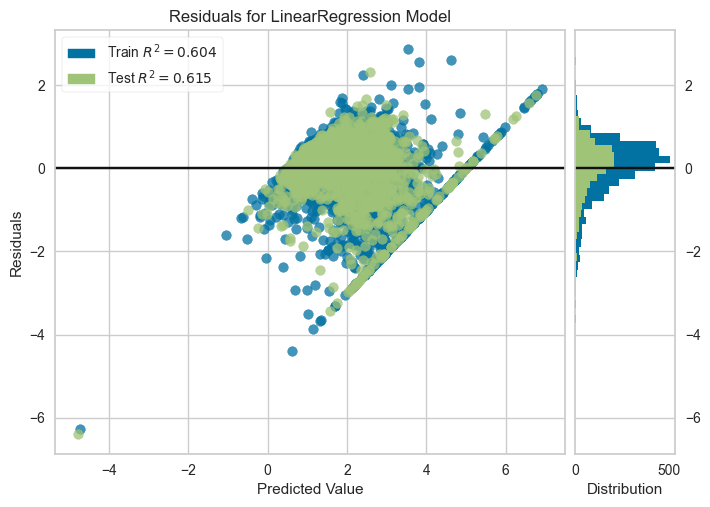

In [11]:
# Step 7: Evaluate the Linear Regression model with plots
# plot_model() generates diagnostic visualizations with one line of code
# Available plots: 'residuals', 'error', 'feature', 'cooks', 'learning', 'vc', etc.

# Residual Plot — checks if residuals are randomly distributed (no pattern = good)
# Left: residuals vs predicted, Right: histogram of residuals
plot_model(lr_pycaret, plot='residuals')

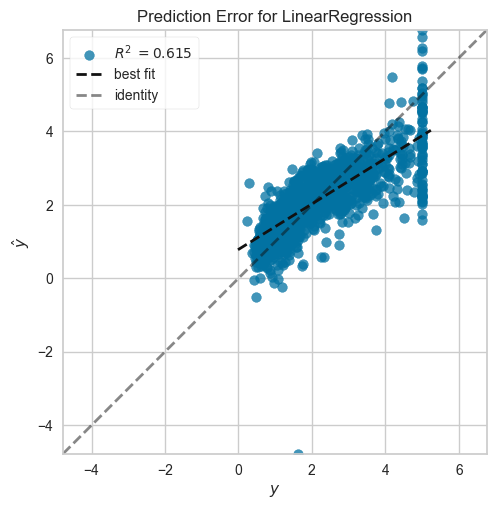

In [12]:
# Prediction Error Plot — shows actual vs predicted values
# Points on the diagonal line = perfect predictions
# Deviation from the line = prediction error
plot_model(lr_pycaret, plot='error')

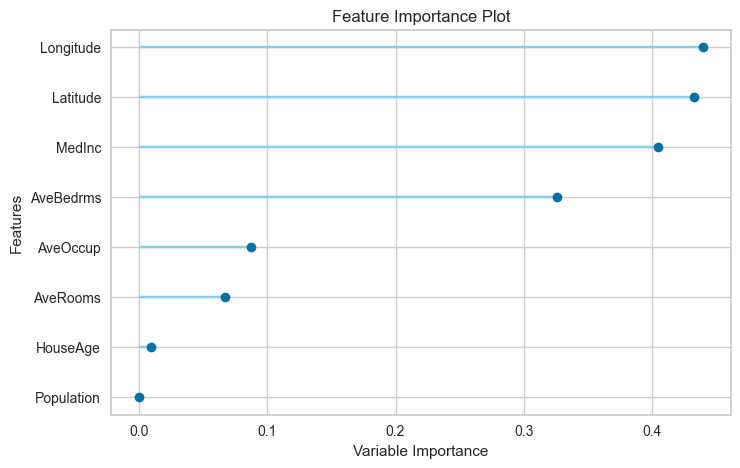

In [13]:
# Feature Importance — which features contribute most to predictions
# Taller bars = more important features for the model's predictions
# Helps decide which features to keep or remove
plot_model(lr_pycaret, plot='feature')

In [14]:
# Step 8: Predict on the held-out test set
# predict_model() runs the trained model on PyCaret's internal test set (30% holdout)
# It adds a 'prediction_label' column with the predicted values
predictions = predict_model(lr_pycaret)
print("Predictions on test set (first 10 rows):")
predictions.head(10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.5158,0.5177,0.7195,0.6153,0.2167,0.3050


Predictions on test set (first 10 rows):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,prediction_label
1501,2.1250,22.0,6.856688,1.468153,903.0,2.875796,40.400002,-122.760002,1.232,0.658566
2586,2.4306,32.0,4.004032,1.149194,1044.0,4.209677,34.200001,-118.379997,1.875,1.604290
2653,3.5603,52.0,4.904306,1.026316,957.0,2.289474,34.090000,-118.250000,2.100,2.297009
1055,2.8021,14.0,6.239175,1.146392,1349.0,2.781443,34.430000,-117.110001,1.112,0.917164
705,6.8695,27.0,6.567358,1.007772,1071.0,2.774611,34.279999,-118.489998,3.194,3.278099
106,1.8576,37.0,2.477564,1.006410,835.0,2.676282,34.090000,-118.309998,1.938,1.617241
589,4.2917,37.0,5.868421,1.029605,788.0,2.592105,37.959999,-122.059998,1.896,2.363449
2468,3.0375,25.0,18.715517,3.327586,248.0,2.137931,39.139999,-120.180000,1.719,0.326157
2413,5.5000,17.0,7.066038,1.069182,973.0,3.059748,32.799999,-117.059998,2.220,2.604366
1600,4.1296,38.0,4.222781,1.083752,1091.0,1.827471,34.020000,-118.389999,3.229,2.601059
